## Exploring the Met Office Global and UK Forecast Datasets

The [UK Met Office](https://www.metoffice.gov.uk/) produces two forecast datasets that are available in near-real-time in the [Microsoft Planetary Computer Data Catalog](https://planetarycomputer.microsoft.com/catalog). One for the entire globe and one that covers just the United Kingdom at a higher resolution.

The datasets are organized into 8 STAC collections that are designed to facilitate multidimensional analysis of the underlying assets:

- Global
  - [Near-surface level collection Met Office global deterministic 10km forecast](https://planetarycomputer.microsoft.com/dataset/met-office-global-deterministic-near-surface)
  - [Whole Atmosphere collection Met Office Global 10km deterministic weather forecast](https://planetarycomputer.microsoft.com/dataset/met-office-global-deterministic-whole-atmosphere)
  - [Height levels collection Met Office Global 10km deterministic weather forecast](https://planetarycomputer.microsoft.com/dataset/met-office-global-deterministic-height)
  - [Pressure levels collection Met Office Global 10km deterministic weather forecast](https://planetarycomputer.microsoft.com/dataset/met-office-global-deterministic-pressure)
  
- UK
  - [Near-surface level collection Met Office UKV 2km deterministic forecast](https://planetarycomputer.microsoft.com/dataset/met-office-uk-deterministic-near-surface)
  - [Whole Atmosphere collection Met Office UKV 2km deterministic forecast](https://planetarycomputer.microsoft.com/dataset/met-office-uk-deterministic-whole-atmosphere)
  - [Height levels collection Met Office UKV 2km deterministic forecast](https://planetarycomputer.microsoft.com/dataset/met-office-uk-deterministic-height)
  - [Pressure levels collection Met Office UKV 2km deterministic forecast](https://planetarycomputer.microsoft.com/dataset/met-office-uk-deterministic-pressure)
  
In this tutorial you will learn how to use targeted filters to query the Planetary Computer's Data Catalog so that you can analyze these rich datasets using `xarray`.

We will use [obspec-utils](https://obspec-utils.readthedocs.io/en/latest/) to open the NetCDF files over the network. obspec-utils is a new library based on [obstore](https://developmentseed.org/obstore/latest/) that provides convenient and efficient mechanisms for connecting xarray to files in object storage.

In [1]:
%pip install obspec-utils -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
from datetime import datetime, timedelta, UTC
from urllib.parse import urlparse
from pathlib import PurePosixPath

import geogif
import matplotlib.pyplot as plt
import xarray as xr
from pyproj import CRS, Transformer
from pystac_client import Client
from obstore.store import AzureStore
from obstore.auth.planetary_computer import PlanetaryComputerCredentialProvider
from obspec_utils.readers import BlockStoreReader, EagerStoreReader


def get_storage_paths(items, asset_key):
    """extract the url prefix and the paths to the asset hrefs for use with
    obstore
    """
    parsed = urlparse(items[0].assets[asset_key].href)
    first_dir = PurePosixPath(parsed.path).parts[1]

    prefix = f"{parsed.scheme}://{parsed.netloc}/{first_dir}/"

    asset_paths = [
        "/".join(PurePosixPath(urlparse(asset.href).path).parts[2:])
        for item in items
        if (asset := item.assets.get(asset_key))
    ]

    return prefix, asset_paths


catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

This tutorial will use the data from a forecast generated on January 29, 2026.

In [4]:
reference_datetime = datetime(2026, 1, 29, 12, tzinfo=UTC)

### UK Collections
The UK collections contain 2 km resolution forecasts for an area centered on the UK. The X and Y coordinates are projected so be aware when doing spatial intersections! These forecasts are updated hourly but the maximum forecast horizon varies depending on the hour at which the forecast was generated.

To see the hourly update structure you can run a query for `PT0000H00M` forecast items for a single day. These items represent the current conditions at the time the forecast was generated (`forecast:reference_time = datetime`).

In [5]:
test_datetime = datetime(2026, 1, 29, tzinfo=UTC)

uk_near_surface_search = catalog.search(
    collections="met-office-uk-deterministic-near-surface",
    filter_lang="cql2-json",
    datetime=[test_datetime, test_datetime + timedelta(days=1) - timedelta(seconds=1)],
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:horizon"},
            "PT0000H00M",
        ],
    },
    sortby="datetime",
)

uk_near_surface_items = uk_near_surface_search.item_collection()

print(
    f"found {len(uk_near_surface_items)} PT0000H00M items for",
    test_datetime.strftime("%Y-%m-%d"),
)

print(
    "The forecasts were generated at the following times:",
    ", ".join(item.datetime.strftime("%H:%M UTC") for item in uk_near_surface_items),
)

found 24 PT0000H00M items for 2026-01-29
The forecasts were generated at the following times: 00:00 UTC, 01:00 UTC, 02:00 UTC, 03:00 UTC, 04:00 UTC, 05:00 UTC, 06:00 UTC, 07:00 UTC, 08:00 UTC, 09:00 UTC, 10:00 UTC, 11:00 UTC, 12:00 UTC, 13:00 UTC, 14:00 UTC, 15:00 UTC, 16:00 UTC, 17:00 UTC, 18:00 UTC, 19:00 UTC, 20:00 UTC, 21:00 UTC, 22:00 UTC, 23:00 UTC


#### UK Near Surface
The UK Near Surface collection contains near-surface forecasts of many variables. Each STAC item represents the forecast for a single time step. We can retrieve the STAC items for the entire forecast that was generated at the reference datetime (defined above) with the following STAC query. Each item's `datetime` property corresponds to the forecast time while `forecast:reference_datetime` refers to the time at which the forecast was generated.

In [6]:
uk_near_surface_search = catalog.search(
    collections="met-office-uk-deterministic-near-surface",
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:reference_datetime"},
            reference_datetime.strftime("%Y-%m-%dT%H:%M:%SZ"),
        ],
    },
    sortby="datetime",
)

uk_near_surface_items = uk_near_surface_search.item_collection()

print(f"found {len(uk_near_surface_items)} items")

print(
    f"assets for {uk_near_surface_items[0].datetime.isoformat()}:",
    list(uk_near_surface_items[0].assets.keys()),
)

found 217 items
assets for 2026-01-29T12:00:00+00:00: ['landsea_mask', 'rainfall_rate', 'snowfall_rate', 'hail_fall_rate', 'wind_gust_at_10m', 'wind_speed_at_10m', 'precipitation_rate', 'height_of_orography', 'pressure_at_surface', 'wind_direction_at_10m', 'temperature_at_surface', 'pressure_at_mean_sea_level', 'visibility_at_screen_level', 'snow_depth_water_equivalent', 'temperature_at_screen_level', 'fog_fraction_at_screen_level', 'sensible_heat_flux_at_surface', 'relative_humidity_at_screen_level', 'radiation_flux_in_uv_downward_at_surface', 'temperature_of_dew_point_at_screen_level', 'radiation_flux_in_longwave_downward_at_surface', 'radiation_flux_in_shortwave_total_downward_at_surface', 'radiation_flux_in_shortwave_direct_downward_at_surface', 'radiation_flux_in_shortwave_diffuse_downward_at_surface']


Not all of the STAC items have the full set of assets! See the collection description to understand the temporal structure with respect to forecast variable. For example, the second item from the search has many fewer assets than the first. 

In [7]:
print(
    f"assets for {uk_near_surface_items[1].datetime.isoformat()}:",
    list(uk_near_surface_items[1].assets.keys()),
)

assets for 2026-01-29T12:15:00+00:00: ['rainfall_rate', 'snowfall_rate', 'hail_fall_rate', 'wind_gust_at_10m', 'wind_speed_at_10m', 'precipitation_rate', 'wind_direction_at_10m', 'pressure_at_mean_sea_level', 'visibility_at_screen_level', 'temperature_at_screen_level', 'temperature_of_dew_point_at_screen_level']


To access the assets over HTTP we can set up an `AzureStore` object store from `obstore` with the `PlanetaryComputerCredentialProvider` that will handle the url signing for us. This approach is very convenient because it will request the signing credentials when needed and refresh those credentials before the expire.

Azure uses the account, container, and a path prefix to determine the credential signing url for an asset so we need to split up the asset hrefs for this purpose.

In [8]:
prefix, uk_wind_speed_asset_paths = get_storage_paths(
    uk_near_surface_items, "wind_speed_at_10m"
)

print(prefix)
print(uk_wind_speed_asset_paths[0])

https://ukmoeuwest.blob.core.windows.net/deterministic/
uk/near-surface/20260129T1200Z/20260129T1200Z-PT0000H00M-wind_speed_at_10m.nc


We will use an `AzureStore` from `obstore` to access files over the network. It will handle asset url signing via the `PlanetaryComputerCredentialProvider`.

In [9]:
store = AzureStore(credential_provider=PlanetaryComputerCredentialProvider(prefix))

In all of the Met Office Deterministic collections each asset contains a single variable. The Near Surface collection assets do not contain variables that have predictions for multiple levels on any other dimensions but some of the other collections (Height Levels and Pressure Levels) do have an additional dimension. 

The underlying NetCDF files have an internal chunking scheme that makes it possible to load small subsets of the data without fetching the entire file over the network but it is important to override xarray's default behavior here because it will result in sub-optimal structures for partial reads.

We can load all of the `wind_speed_at_10m` assets into a 3-dimensional datacube (time, y, x) using `xarray.open_mfdataset`. Since the NetCDF files for the UK forecast collections are relatively small, we can use the `EagerStoreReader` from `obspec_utils` which will eagerly cache the entire file in memory to make subsequent read operations faster.

In [11]:
uk_default_chunk_sizes = {
    "time": 1,
    "projection_y_coordinate": 256,
    "projection_x_coordinate": 256,
}

uk_wind_speed_ds = xr.open_mfdataset(
    [EagerStoreReader(store, path) for path in uk_wind_speed_asset_paths],
    engine="h5netcdf",
    chunks=uk_default_chunk_sizes,
    decode_times=True,
    decode_timedelta=True,
    concat_dim="time",
    combine="nested",
    parallel=True,
)

uk_wind_speed_ds

<xarray.Dataset>
Dimensions:                       (time: 91, projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * projection_y_coordinate       (projection_y_coordinate) float32 -1.036e+0...
  * projection_x_coordinate       (projection_x_coordinate) float32 -1.158e+0...
    forecast_period               (time) timedelta64[ns] 00:00:00 ... 2 days ...
    forecast_reference_time       datetime64[ns] 2026-01-29T12:00:00
    height                        float32 10.0
  * time                          (time) datetime64[ns] 2026-01-29T12:00:00 ....
Dimensions without coordinates: bnds
Data variables:
    wind_speed                    (time, projection_y_coordinate, projection_x_coordinate) float32 dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    lambert_azimuthal_equal_area  (time) int32 -2147483647 ... -2147483647
    projection_y_coordinate_bnds  (time, projection_y_coordinate, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
    projection_x_coordinate_bnds  (time, projection_x_coordinate, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
Attributes:
    history:                      2026-01-29T13:15:01Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

The time series can be plotted in a gif using `geogif`

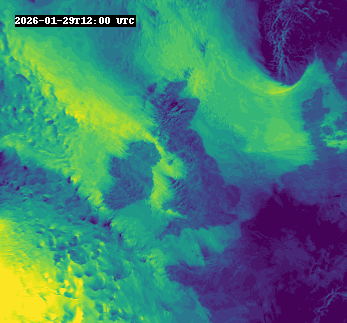

In [33]:
geogif.dgif(
    (
        uk_wind_speed_ds["wind_speed"]
        .reindex(  # need to flip the y coordinates to orient the image properly
            projection_y_coordinate=list(
                reversed(uk_wind_speed_ds.projection_y_coordinate)
            )
        )
        .coarsen(
            projection_y_coordinate=3,
            projection_x_coordinate=3,
            boundary="trim",
        )
        .mean()
    ),
    date_format="%Y-%m-%dT%H:%M UTC",
).compute()

You may be interested in doing an analysis involving multiple variables. To do that, you can load the asset paths for the other variables into separate `xarray.Datasets` then merge them with `xarray.merge`. This works because the STAC items in each collection can be readily combined along all of the important dimensions (time, y, x).

In [13]:
uk_surface_datasets = [uk_wind_speed_ds]

for variable in ["temperature_at_surface", "pressure_at_surface"]:
    _, asset_paths = get_storage_paths(uk_near_surface_items, variable)
    ds = xr.open_mfdataset(
        [EagerStoreReader(store, path) for path in asset_paths],
        engine="h5netcdf",
        chunks=uk_default_chunk_sizes,
        decode_times=True,
        decode_timedelta=True,
        concat_dim="time",
        combine="nested",
        parallel=True,
    )
    uk_surface_datasets.append(ds)

uk_surface_cube = xr.merge(
    uk_surface_datasets,
    compat="minimal",
)

uk_surface_cube

<xarray.Dataset>
Dimensions:                  (projection_y_coordinate: 970,
                              projection_x_coordinate: 1042, time: 91)
Coordinates:
  * projection_y_coordinate  (projection_y_coordinate) float32 -1.036e+06 ......
  * projection_x_coordinate  (projection_x_coordinate) float32 -1.158e+06 ......
  * time                     (time) datetime64[ns] 2026-01-29T12:00:00 ... 20...
    forecast_reference_time  datetime64[ns] 2026-01-29T12:00:00
    height                   float32 10.0
Data variables:
    wind_speed               (time, projection_y_coordinate, projection_x_coordinate) float32 dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    surface_temperature      (time, projection_y_coordinate, projection_x_coordinate) float32 dask.array<chunksize=(4, 256, 256), meta=np.ndarray>
    surface_air_pressure     (time, projection_y_coordinate, projection_x_coordinate) float32 dask.array<chunksize=(4, 256, 256), meta=np.ndarray>
Attributes:
    history:                      2026-01-29T13:15:01Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

To extract the forecast values at a location we must ensure the coordinates match the CRS of the x/y coordinates in the array. This example pulls the forecast for all variables and time steps at the Met Office headquarters!

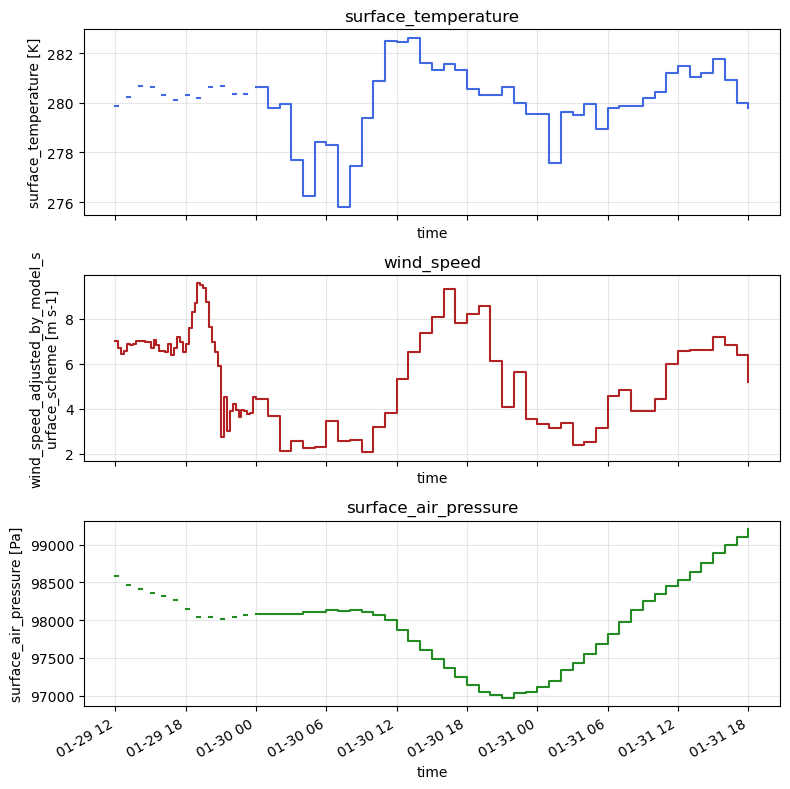

In [35]:
projected_crs = CRS(uk_near_surface_items[0].properties["proj:wkt2"])
transformer = Transformer.from_crs(CRS("epsg:4326"), projected_crs, always_xy=True)

lon, lat = -3.47, 50.73
projected_coords = transformer.transform(lon, lat)

local_forecast = uk_surface_cube.sel(
    projection_x_coordinate=projected_coords[0],
    projection_y_coordinate=projected_coords[1],
    method="nearest",
)


fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 8), sharex=True)

variables = ["surface_temperature", "wind_speed", "surface_air_pressure"]
colors = ["royalblue", "firebrick", "forestgreen"]

for i, (variable, color) in enumerate(zip(variables, colors)):
    local_forecast[variable].plot.step(ax=axes[i], color=color, where="post")
    axes[i].set_title(variable)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### UK Whole Atmosphere

You can follow the same access pattern for the UK Whole Atmosphere collection. There are not as many forecast time steps in this collection so there are going to be fewer STAC items for the initial query.

In [16]:
uk_whole_atmosphere_search = catalog.search(
    collections="met-office-uk-deterministic-whole-atmosphere",
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:reference_datetime"},
            reference_datetime.strftime("%Y-%m-%dT%H:%M:%SZ"),
        ],
    },
    sortby="datetime",
)

uk_whole_atmosphere_items = uk_whole_atmosphere_search.item_collection()

print(f"found {len(uk_whole_atmosphere_items)} items")

print(
    f"assets for {uk_whole_atmosphere_items[0].datetime.isoformat()}:",
    list(uk_whole_atmosphere_items[0].assets.keys()),
)

found 91 items
assets for 2026-01-29T12:00:00+00:00: ['CAPE_surface', 'cloud_amount_of_low_cloud', 'cloud_amount_of_high_cloud', 'cloud_amount_of_total_cloud', 'cloud_amount_of_medium_cloud', 'height_AGL_at_freezing_level', 'cloud_amount_below_1000ft_ASL', 'CAPE_most_unstable_below_500hPa', 'height_AGL_at_wet_bulb_freezing_level', 'height_AGL_at_cloud_base_where_cloud_cover_2p5_oktas']


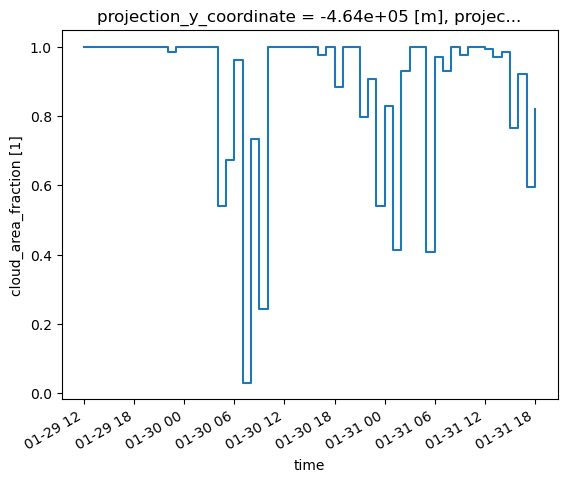

In [17]:
_, uk_total_cloud_asset_paths = get_storage_paths(
    uk_whole_atmosphere_items, "cloud_amount_of_total_cloud"
)

uk_total_cloud_ds = xr.open_mfdataset(
    [EagerStoreReader(store, path) for path in uk_total_cloud_asset_paths],
    engine="h5netcdf",
    chunks=uk_default_chunk_sizes,
    decode_times=True,
    decode_timedelta=True,
    concat_dim="time",
    combine="nested",
    parallel=True,
)

local_forecast = uk_total_cloud_ds["cloud_area_fraction"].sel(
    projection_x_coordinate=projected_coords[0],
    projection_y_coordinate=projected_coords[1],
    method="nearest",
)

_ = local_forecast.plot.step(where="post")

#### UK Height Levels

The UK Height Levels collection contains forecasts of four variables at various height levels in the atmosphere: `wind_speed_on_height_levels`, `temperature_on_height_levels`, `cloud_amount_on_height_levels`, `wind_direction_on_height_levels`. Each NetCDF asset represents a 3-D array (height, y, x) instead of a 2-D array like the Whole Atmosphere and Near Surface collections.

In [18]:
uk_height_search = catalog.search(
    collections="met-office-uk-deterministic-height",
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:reference_datetime"},
            reference_datetime.strftime("%Y-%m-%dT%H:%M:%SZ"),
        ],
    },
    sortby="datetime",
)

uk_height_items = uk_height_search.item_collection()

print(f"found {len(uk_height_items)} items")

print(
    f"assets for {uk_height_items[0].datetime.isoformat()}:",
    list(uk_height_items[0].assets.keys()),
)

found 55 items
assets for 2026-01-29T12:00:00+00:00: ['wind_speed_on_height_levels', 'temperature_on_height_levels', 'cloud_amount_on_height_levels', 'wind_direction_on_height_levels']


Since each file contains ~56x more data than the flat NetCDF files we have worked with so far we will switch to using the `BlockStoreReader` which will not eagerly cache the entire contents of each file when reading it. This will allow us to defer most of the network requests until the point when we know exactly which parts of each file we want to read.

We also need to adjustthe `chunks` specification and instruct `xarray` to set the chunk size to 1 along the `height` dimension. If we don't do this, then it will set a larger chunk size that will result in lots of unnecessary downloads.

In [34]:
uk_height_datasets = {}

for variable in ["temperature_on_height_levels", "wind_speed_on_height_levels"]:
    print("loading", variable)
    _, asset_paths = get_storage_paths(uk_height_items, variable)
    ds = xr.open_mfdataset(
        [BlockStoreReader(store, path) for path in asset_paths],
        engine="h5netcdf",
        chunks={"height": 1, **uk_default_chunk_sizes},
        decode_times=True,
        decode_timedelta=True,
        concat_dim="time",
        combine="nested",
        parallel=True,
    )
    uk_height_datasets[variable] = ds

uk_height_cube = xr.merge(
    uk_height_datasets.values(),
    compat="minimal",
)

uk_height_cube

loading temperature_on_height_levels
loading wind_speed_on_height_levels


<xarray.Dataset>
Dimensions:                       (time: 55, height: 56,
                                   projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * height                        (height) float32 5.0 10.0 ... 6.75e+03 7.5e+03
  * projection_y_coordinate       (projection_y_coordinate) float32 -1.036e+0...
  * projection_x_coordinate       (projection_x_coordinate) float32 -1.158e+0...
    forecast_period               (time) timedelta64[ns] 00:00:00 ... 2 days ...
    forecast_reference_time       datetime64[ns] 2026-01-29T12:00:00
  * time                          (time) datetime64[ns] 2026-01-29T12:00:00 ....
Dimensions without coordinates: bnds
Data variables:
    air_temperature               (time, height, projection_y_coordinate, projection_x_coordinate) float32 dask.array<chunksize=(1, 1, 256, 256), meta=np.ndarray>
    lambert_azimuthal_equal_area  (time) int32 -2147483647 ... -2147483647
    projection_y_coordinate_bnds  (time, projection_y_coordinate, bnds) float32 ...
    projection_x_coordinate_bnds  (time, projection_x_coordinate, bnds) float32 ...
    wind_speed                    (time, height, projection_y_coordinate, projection_x_coordinate) float32 dask.array<chunksize=(1, 1, 256, 256), meta=np.ndarray>
Attributes:
    history:                      2026-01-29T13:14:57Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

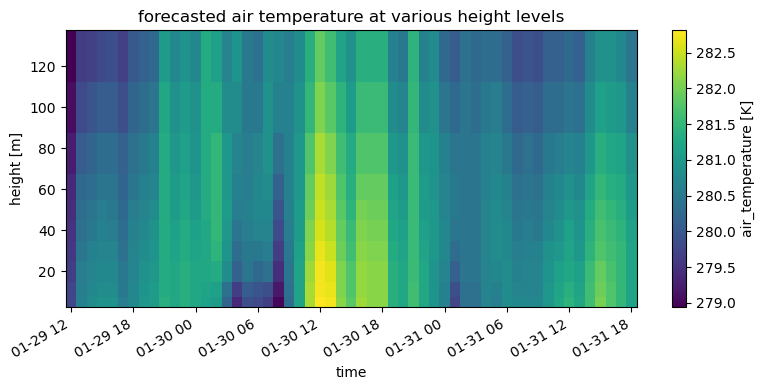

In [36]:
local_forecast = uk_height_cube.isel(height=slice(0, 10)).sel(
    projection_x_coordinate=projected_coords[0],
    projection_y_coordinate=projected_coords[1],
    method="nearest",
)

plt.figure(figsize=(8, 4))

_ = local_forecast["air_temperature"].plot(x="time")
plt.title("forecasted air temperature at various height levels")
plt.tight_layout()
plt.show()

#### UK Pressure Levels

The last UK collection to cover is the Pressure Levels collection. For this collection we will try a different type of search. Instead of pulling all of the time steps for a single forecast, we will examine the PT00H forecasts from a series of different forecasts. These STAC items will represent the current conditions at the time that each forecast was generated.

Instead of filtering on `forecast:reference_datetime` we will filter down to items where `forecast:horizon` is `PT0000H00M` (zero-hour forecast).

In [23]:
uk_pressure_search = catalog.search(
    collections="met-office-uk-deterministic-pressure",
    filter_lang="cql2-json",
    datetime=[reference_datetime, reference_datetime + timedelta(days=1)],
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:horizon"},
            "PT0000H00M",
        ],
    },
    sortby="datetime",
)

uk_pressure_items = uk_pressure_search.item_collection()

print(f"found {len(uk_pressure_items)} items")

print(
    f"assets for {uk_pressure_items[0].datetime.isoformat()}:",
    list(uk_pressure_items[0].assets.keys()),
)

found 25 items
assets for 2026-01-29T12:00:00+00:00: ['wind_speed_on_pressure_levels', 'temperature_on_pressure_levels', 'wind_direction_on_pressure_levels', 'relative_humidity_on_pressure_levels', 'geopotential_height_on_pressure_levels', 'wet_bulb_potential_temperature_on_pressure_levels']


Now load all of the assets into a single `xarray.Dataset` with the chunk size for the `pressure` dimension set to 1.

In [25]:
uk_pressure_datasets = {}

for variable in [
    "wet_bulb_potential_temperature_on_pressure_levels",
    "temperature_on_pressure_levels",
]:
    print("loading", variable)
    _, asset_paths = get_storage_paths(uk_pressure_items, variable)
    ds = xr.open_mfdataset(
        [BlockStoreReader(store, path) for path in asset_paths],
        engine="h5netcdf",
        chunks={"pressure": 1, **uk_default_chunk_sizes},
        decode_times=True,
        decode_timedelta=True,
        concat_dim="time",
        combine="nested",
        parallel=True,
    )
    uk_pressure_datasets[variable] = ds

uk_pressure_cube = xr.merge(
    uk_pressure_datasets.values(),
    compat="minimal",
)

uk_pressure_cube

loading wet_bulb_potential_temperature_on_pressure_levels
loading temperature_on_pressure_levels


<xarray.Dataset>
Dimensions:                         (pressure: 33,
                                     projection_y_coordinate: 970,
                                     projection_x_coordinate: 1042, time: 25,
                                     bnds: 2)
Coordinates:
  * pressure                        (pressure) float32 1e+03 2e+03 ... 1e+05
  * projection_y_coordinate         (projection_y_coordinate) float32 -1.036e...
  * projection_x_coordinate         (projection_x_coordinate) float32 -1.158e...
  * time                            (time) datetime64[ns] 2026-01-29T12:00:00...
    forecast_period                 timedelta64[ns] 00:00:00
    forecast_reference_time         (time) datetime64[ns] 2026-01-29T12:00:00...
Dimensions without coordinates: bnds
Data variables:
    wet_bulb_potential_temperature  (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 dask.array<chunksize=(1, 24, 256, 256), meta=np.ndarray>
    lambert_azimuthal_equal_area    (time) int32 -2147483647 ... -2147483647
    projection_y_coordinate_bnds    (time, projection_y_coordinate, bnds) float32 ...
    projection_x_coordinate_bnds    (time, projection_x_coordinate, bnds) float32 ...
    air_temperature                 (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 dask.array<chunksize=(1, 1, 256, 256), meta=np.ndarray>
Attributes:
    ancillary_variables:          flag
    history:                      2026-01-29T13:14:55Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

Some variables do not have observations at all pressure levels. For example, `wet_bulb_potential_temperature` only has values at three of the `pressure` coordinates.

In [26]:
uk_pressure_datasets["wet_bulb_potential_temperature_on_pressure_levels"]

<xarray.Dataset>
Dimensions:                         (time: 25, pressure: 3,
                                     projection_y_coordinate: 970,
                                     projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * pressure                        (pressure) float32 8.5e+04 7e+04 5e+04
  * projection_y_coordinate         (projection_y_coordinate) float32 -1.036e...
  * projection_x_coordinate         (projection_x_coordinate) float32 -1.158e...
    forecast_period                 timedelta64[ns] 00:00:00
    forecast_reference_time         (time) datetime64[ns] 2026-01-29T12:00:00...
  * time                            (time) datetime64[ns] 2026-01-29T12:00:00...
Dimensions without coordinates: bnds
Data variables:
    wet_bulb_potential_temperature  (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 dask.array<chunksize=(1, 1, 256, 256), meta=np.ndarray>
    lambert_azimuthal_equal_area    (time) int32 -2147483647 ... -2147483647
    projection_y_coordinate_bnds    (time, projection_y_coordinate, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
    projection_x_coordinate_bnds    (time, projection_x_coordinate, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
    flag                            (time, pressure, projection_y_coordinate, projection_x_coordinate) int8 dask.array<chunksize=(1, 1, 256, 256), meta=np.ndarray>
Attributes:
    ancillary_variables:          flag
    history:                      2026-01-29T13:14:55Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

FYI: This causes the `wet_bulb_potential_temperature` array in the full `uk_pressure_cube` to be sparsely filled along the full `pressure` dimension.

In [27]:
(
    uk_pressure_cube["wet_bulb_potential_temperature"]
    .isel(projection_x_coordinate=0, projection_y_coordinate=0)
    .compute()
)

<xarray.DataArray 'wet_bulb_potential_temperature' (time: 25, pressure: 33)>
array([[     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan, 282.375 ,      nan,      nan,      nan,
        279.375 ,      nan,      nan, 280.125 ,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan, 283.125 ,      nan,      nan,      nan,
        280.    ,      nan,      nan, 280.    ,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan, 283.5   ,      nan,      nan,      nan,
        280.0625,      nan,      nan, 280.    ,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
...
        280.125 ,      nan,      nan, 280.375 ,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan, 280.625 ,      nan,      nan,      nan,
        278.875 ,      nan,      nan, 278.9375,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan, 280.75  ,      nan,      nan,      nan,
        278.25  ,      nan,      nan, 278.5   ,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan, 280.5   ,      nan,      nan,      nan,
        278.375 ,      nan,      nan, 278.5   ,      nan,      nan,
             nan,      nan,      nan]], dtype=float32)
Coordinates:
  * pressure                 (pressure) float32 1e+03 2e+03 ... 9.75e+04 1e+05
    projection_y_coordinate  float32 -1.036e+06
    projection_x_coordinate  float32 -1.158e+06
  * time                     (time) datetime64[ns] 2026-01-29T12:00:00 ... 20...
    forecast_period          timedelta64[ns] 00:00:00
    forecast_reference_time  (time) datetime64[ns] 2026-01-29T12:00:00 ... 20...
Attributes:
    least_significant_digit:  1
    standard_name:            wet_bulb_potential_temperature
    units:                    K
    grid_mapping:             lambert_azimuthal_equal_area
    ancillary_variables:      flag

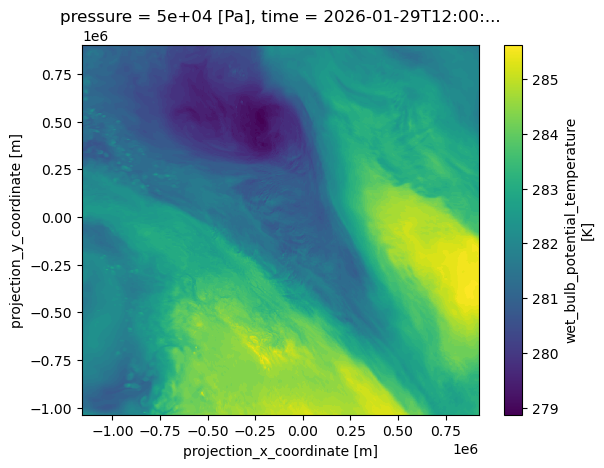

In [37]:
(
    uk_pressure_cube["wet_bulb_potential_temperature"]
    .dropna(dim="pressure")
    .isel(pressure=0)
    .isel(time=0)
    .plot.imshow()
)

### Global Collections

The Global collections contain lower resolution (10 km) forecasts that are updated every 6 hours. The global forecasts contain fewer variables and fewer time steps than the corresponding UK forecasts so keep that in mind when you are planning your analysis.

You can run a query for `PT0000H00M` forecasts for a single day to see that there are four new forecasts generated each day.

In [38]:
test_datetime = datetime(2026, 1, 29, tzinfo=UTC)

global_near_surface_search = catalog.search(
    collections="met-office-global-deterministic-near-surface",
    filter_lang="cql2-json",
    datetime=[test_datetime, test_datetime + timedelta(days=1) - timedelta(seconds=1)],
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:horizon"},
            "PT0000H00M",
        ],
    },
    sortby="datetime",
)

global_near_surface_items = global_near_surface_search.item_collection()

print(
    f"found {len(global_near_surface_items)} PT0000H00M items for",
    test_datetime.strftime("%Y-%m-%d"),
)

print(
    "The forecasts were generated at the following times:",
    ", ".join(
        item.datetime.strftime("%Y-%m-%dT%H:%MZ") for item in global_near_surface_items
    ),
)

found 4 PT0000H00M items for 2026-01-29
The forecasts were generated at the following times: 2026-01-29T00:00Z, 2026-01-29T06:00Z, 2026-01-29T12:00Z, 2026-01-29T18:00Z


This means that for the global collections **you will only be able to query for `forecast:reference_time` values where the hour is either 0, 6, 12, or 18!**

### Global near-surface

The Global Near Surface collection contains forecasts of many variables representing conditions near the earth's surface.

We can get the STAC items for the entire 89 time step forecast that was generated at our chosen `forecast:reference_datetime` with the following STAC query. Each item's `datetime` property corresponds to the forecast time while `forecast:reference_datetime` refers to the time at which the forecast was generated.

In [39]:
global_near_surface_search = catalog.search(
    collections="met-office-global-deterministic-near-surface",
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:reference_datetime"},
            reference_datetime.strftime("%Y-%m-%dT%H:%M:%SZ"),
        ],
    },
    sortby="datetime",
)

global_near_surface_items = global_near_surface_search.item_collection()

print(f"found {len(global_near_surface_items)} items")

print(
    f"assets for {global_near_surface_items[0].datetime.isoformat()}:",
    list(global_near_surface_items[0].assets.keys()),
)

found 89 items
assets for 2026-01-29T12:00:00+00:00: ['rainfall_rate', 'snowfall_rate', 'wind_gust_at_10m', 'wind_speed_at_10m', 'precipitation_rate', 'height_of_orography', 'wind_direction_at_10m', 'temperature_at_surface', 'pressure_at_mean_sea_level', 'visibility_at_screen_level', 'snow_depth_water_equivalent', 'temperature_at_screen_level', 'fog_fraction_at_screen_level', 'rainfall_rate_from_convection', 'snowfall_rate_from_convection', 'relative_humidity_at_screen_level', 'radiation_flux_in_uv_downward_at_surface', 'temperature_of_dew_point_at_screen_level', 'radiation_flux_in_longwave_downward_at_surface', 'radiation_flux_in_shortwave_total_downward_at_surface', 'radiation_flux_in_shortwave_direct_downward_at_surface']


Now we can lazily load all 89 of the forecast time steps into an xarray Dataset with `xarray.open_mfdataset`. xarray will intelligently concatenate the arrays along the relevant dimensions but we do need to specify the chunking scheme in order to structure the data for efficient subsetting. The native chunk size of these NetCDF files is (128, 128) along the latitude and longitude dimension which results in a very small chunk size. Increasing that to (256, 256) will reduce the number of requests that we need to make for any spatial subset read operations but will result in fetching more than the minimum data required.

In [40]:
global_default_chunk_sizes = {"time": 1, "latitude": 256, "longitude": 256}

The NetCDF assets for the global collections are significantly larger than the corresponding UK assets, so we are using the `BlockStoreReader` rather than the `EagerStoreReader` in order to avoid pre-fetching all of the data.

**Note:** These examples build on material from the UK collections examples

In [41]:
prefix, global_surface_temp_asset_paths = get_storage_paths(
    global_near_surface_items, "temperature_at_surface"
)

store = AzureStore(credential_provider=PlanetaryComputerCredentialProvider(prefix))

global_surface_temp_ds = xr.open_mfdataset(
    [BlockStoreReader(store, path) for path in global_surface_temp_asset_paths],
    engine="h5netcdf",
    chunks=global_default_chunk_sizes,
    decode_times=True,
    decode_timedelta=True,
    concat_dim="time",
    combine="nested",
    parallel=True,
)

global_surface_temp_ds

<xarray.Dataset>
Dimensions:                  (time: 89, latitude: 1920, longitude: 2560, bnds: 2)
Coordinates:
  * latitude                 (latitude) float32 -89.95 -89.86 ... 89.86 89.95
  * longitude                (longitude) float32 -179.9 -179.8 ... 179.8 179.9
    forecast_period          (time) timedelta64[ns] 00:00:00 ... 7 days 00:00:00
    forecast_reference_time  datetime64[ns] 2026-01-29T12:00:00
  * time                     (time) datetime64[ns] 2026-01-29T12:00:00 ... 20...
Dimensions without coordinates: bnds
Data variables:
    surface_temperature      (time, latitude, longitude) float32 dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    latitude_longitude       (time) int32 -2147483647 ... -2147483647
    latitude_bnds            (time, latitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
    longitude_bnds           (time, longitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
Attributes:
    history:                      2026-01-29T15:11:06Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT168H
    mosg__grid_domain:            global
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    gl_det
    source:                       Met Office Unified Model
    title:                        Global Model Forecast on Global 10 km Stand...
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

Notice how the time steps get further apart towards the end of the full forecast. 

The full `surface_temperature` array for the global forecast run is 1.63 GB. If we are only interested in the forecast for a spatial subset we can avoid downloading all of those bytes!

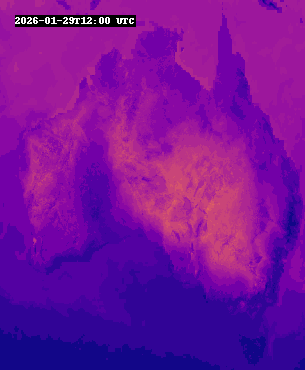

In [49]:
au_bbox = 110.926, -44.079, 153.853, -9.339

au_surface_temp = (
    global_surface_temp_ds["surface_temperature"]
    .sel(
        longitude=slice(au_bbox[0], au_bbox[2]),
        latitude=slice(au_bbox[1], au_bbox[3]),
    )
    .isel(time=slice(0, 24))
)

geogif.dgif(
    (
        au_surface_temp.reindex(
            # need to flip the y coordinates to orient the image properly
            latitude=list(reversed(au_surface_temp.latitude))
        )
    ),
    cmap="plasma",
    date_format="%Y-%m-%dT%H:%M UTC",
    fps=6,
).compute()

#### Global Whole Atmosphere

The Global Whole Atmosphere collection contains forecasts of variables that represent conditions across the entire atmosphere.

In [50]:
global_whole_atmosphere_search = catalog.search(
    collections="met-office-global-deterministic-whole-atmosphere",
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:reference_datetime"},
            reference_datetime.strftime("%Y-%m-%dT%H:%M:%SZ"),
        ],
    },
    sortby="datetime",
)

global_whole_atmosphere_items = global_whole_atmosphere_search.item_collection()

print(f"found {len(global_whole_atmosphere_items)} items")

print(
    f"assets for {global_whole_atmosphere_items[0].datetime.isoformat()}:",
    list(global_whole_atmosphere_items[0].assets.keys()),
)

found 89 items
assets for 2026-01-29T12:00:00+00:00: ['CIN_surface', 'CAPE_surface', 'pressure_at_tropopause', 'cloud_amount_of_low_cloud', 'temperature_at_tropopause', 'cloud_amount_of_high_cloud', 'CIN_mixed_layer_lowest_500m', 'cloud_amount_of_total_cloud', 'CAPE_mixed_layer_lowest_500m', 'cloud_amount_of_medium_cloud', 'cloud_amount_below_1000ft_ASL', 'CIN_most_unstable_below_500hPa', 'CAPE_most_unstable_below_500hPa', 'cloud_amount_of_total_convective_cloud']


We can load the 3-D datacube of one of the variables like this:

In [51]:
_, global_pressure_at_tropopause_asset_paths = get_storage_paths(
    global_whole_atmosphere_items, "pressure_at_tropopause"
)

global_pressure_at_tropopause_ds = xr.open_mfdataset(
    [
        BlockStoreReader(store, path)
        for path in global_pressure_at_tropopause_asset_paths
    ],
    engine="h5netcdf",
    chunks=global_default_chunk_sizes,
    decode_times=True,
    decode_timedelta=True,
    concat_dim="time",
    combine="nested",
    parallel=True,
)

global_pressure_at_tropopause_ds

<xarray.Dataset>
Dimensions:                  (time: 89, latitude: 1920, longitude: 2560, bnds: 2)
Coordinates:
  * latitude                 (latitude) float32 -89.95 -89.86 ... 89.86 89.95
  * longitude                (longitude) float32 -179.9 -179.8 ... 179.8 179.9
    forecast_period          (time) timedelta64[ns] 00:00:00 ... 7 days 00:00:00
    forecast_reference_time  datetime64[ns] 2026-01-29T12:00:00
  * time                     (time) datetime64[ns] 2026-01-29T12:00:00 ... 20...
Dimensions without coordinates: bnds
Data variables:
    tropopause_air_pressure  (time, latitude, longitude) float32 dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    latitude_longitude       (time) int32 -2147483647 ... -2147483647
    latitude_bnds            (time, latitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
    longitude_bnds           (time, longitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
Attributes:
    history:                      2026-01-29T15:11:29Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT168H
    mosg__grid_domain:            global
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    gl_det
    source:                       Met Office Unified Model
    title:                        Global Model Forecast on Global 10 km Stand...
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

You can extract the forecast values at a single point using the `sel` method with a lat/lon pair. This will be fast because xarray will only read a single chunk from each NetCDF file to extract the values at the specified location!

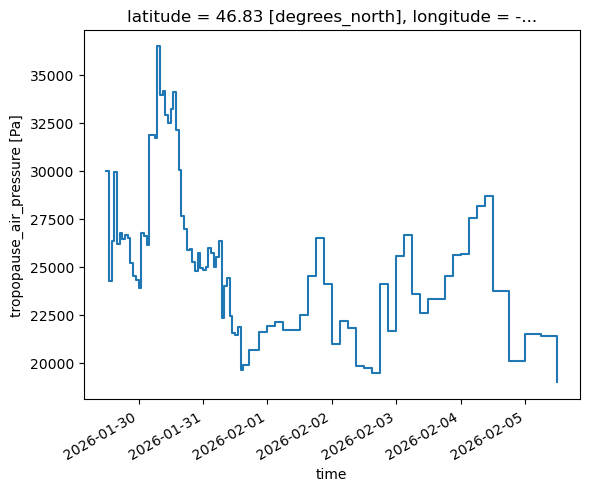

In [52]:
local_forecast = global_pressure_at_tropopause_ds["tropopause_air_pressure"].sel(
    latitude=46.8, longitude=-92.1, method="nearest"
)

local_forecast.plot.step(where="post")

#### Global Height

The Global Height Levels collection contains forecasts of cloud volume at various height levels in the atmosphere. 

In [53]:
global_height_search = catalog.search(
    collections="met-office-global-deterministic-height",
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:reference_datetime"},
            reference_datetime.strftime("%Y-%m-%dT%H:%M:%SZ"),
        ],
    },
    sortby="datetime",
)

global_height_items = global_height_search.item_collection()

print(f"found {len(global_height_items)} items")

print(
    f"assets for {global_height_items[0].datetime.isoformat()}:",
    list(global_height_items[0].assets.keys()),
)

found 89 items
assets for 2026-01-29T12:00:00+00:00: ['cloud_amount_on_height_levels']


**Note:** It is really important to specify `chunks` for this dataset. By default, `xarray.open_mfdataset` will load all of the height levels into just two chunks which means that you could inadvertently fetch data for ~20 height levels even when you are only selecting a single height level!

In [54]:
prefix, global_height_cloud_amount_asset_paths = get_storage_paths(
    global_height_items, "cloud_amount_on_height_levels"
)


global_height_cloud_amount_ds = xr.open_mfdataset(
    [BlockStoreReader(store, path) for path in global_height_cloud_amount_asset_paths],
    engine="h5netcdf",
    chunks={"height": 1, **global_default_chunk_sizes},
    decode_times=True,
    decode_timedelta=True,
    concat_dim="time",
    combine="nested",
    parallel=True,
)

global_height_cloud_amount_ds

<xarray.Dataset>
Dimensions:                                    (time: 89, height: 33,
                                                latitude: 1920,
                                                longitude: 2560, bnds: 2)
Coordinates:
  * height                                     (height) float32 5.0 ... 6e+03
  * latitude                                   (latitude) float32 -89.95 ... ...
  * longitude                                  (longitude) float32 -179.9 ......
    forecast_period                            (time) timedelta64[ns] 00:00:0...
    forecast_reference_time                    datetime64[ns] 2026-01-29T12:0...
  * time                                       (time) datetime64[ns] 2026-01-...
Dimensions without coordinates: bnds
Data variables:
    cloud_volume_fraction_in_atmosphere_layer  (time, height, latitude, longitude) float32 dask.array<chunksize=(1, 1, 256, 256), meta=np.ndarray>
    latitude_longitude                         (time) int32 -2147483647 ... -...
    latitude_bnds                              (time, latitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
    longitude_bnds                             (time, longitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
Attributes:
    history:                      2026-01-29T15:13:50Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT168H
    mosg__grid_domain:            global
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    gl_det
    source:                       Met Office Unified Model
    title:                        Global Model Forecast on Global 10 km Stand...
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

To get the forecast values for a location at 5 of the height levels we can use the `sel` and `isel` methods. When we read the data from the `local_forecast` subset xarray will perform targeted network requests for just the data included in our desired range of height levels and for the chunks that overlap the specified coordinates.

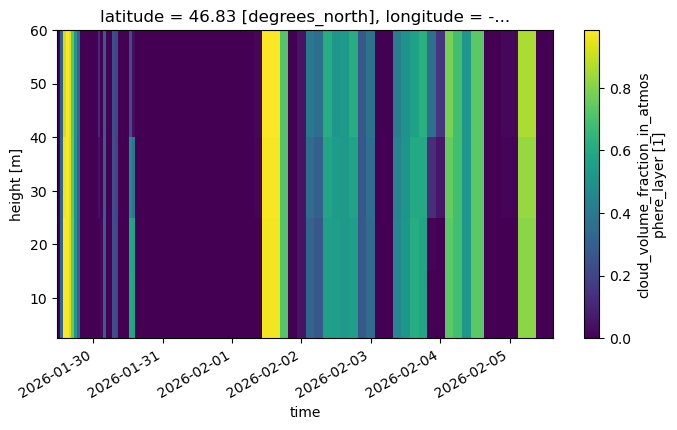

In [55]:
global_height_cloud_amount_local_forecast = (
    global_height_cloud_amount_ds["cloud_volume_fraction_in_atmosphere_layer"]
    .sel(latitude=46.8, longitude=-92.1, method="nearest")
    .isel(height=slice(0, 5))
)

plt.figure(figsize=(8, 4))
_ = global_height_cloud_amount_local_forecast.plot(x="time")
plt.show()

We can also select specific slices of the entire global dataset and visualize the change over time with a gif. This example plucks the 100 m height layer and the first 24 time steps from the forecast.

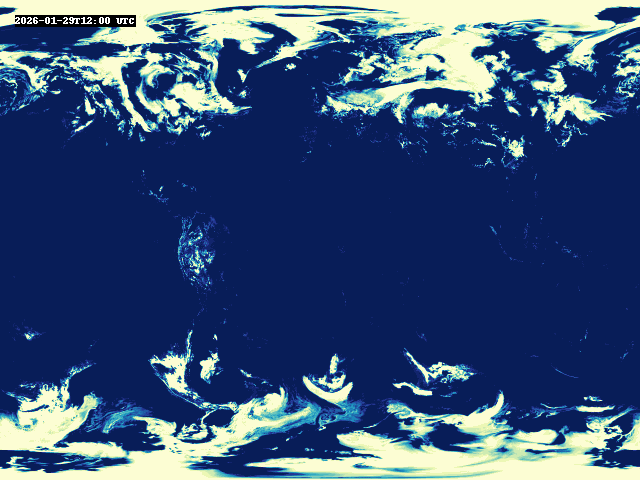

In [58]:
geogif.dgif(
    (
        global_height_cloud_amount_ds["cloud_volume_fraction_in_atmosphere_layer"]
        .sel(height=100)
        .isel(time=slice(0, 24))
        .reindex(  # need to flip the y coordinates to orient the image properly
            latitude=list(reversed(global_height_cloud_amount_ds.latitude))
        )
        .coarsen(
            latitude=4,
            longitude=4,
            boundary="trim",
        )
        .mean()
    ),
    cmap="YlGnBu_r",
    date_format="%Y-%m-%dT%H:%M UTC",
).compute()

#### Global Pressure

The Global Pressure collection contains forecasts of variables along a gradient of pressure levels

In [59]:
global_pressure_search = catalog.search(
    collections="met-office-global-deterministic-pressure",
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:reference_datetime"},
            reference_datetime.strftime("%Y-%m-%dT%H:%M:%SZ"),
        ],
    },
    sortby="datetime",
)

global_pressure_items = global_pressure_search.item_collection()

print(f"found {len(global_pressure_items)} items")

print(
    f"assets for {global_pressure_items[0].datetime.isoformat()}:",
    list(global_pressure_items[0].assets.keys()),
)

found 89 items
assets for 2026-01-29T12:00:00+00:00: ['wind_speed_on_pressure_levels', 'temperature_on_pressure_levels', 'wind_direction_on_pressure_levels', 'relative_humidity_on_pressure_levels', 'geopotential_height_on_pressure_levels', 'wind_vertical_velocity_on_pressure_levels', 'wet_bulb_potential_temperature_on_pressure_levels']


In [60]:
_, global_rh_pressure_asset_paths = get_storage_paths(
    global_pressure_items, "relative_humidity_on_pressure_levels"
)
global_rh_pressure_ds = xr.open_mfdataset(
    [BlockStoreReader(store, path) for path in global_rh_pressure_asset_paths],
    engine="h5netcdf",
    chunks={"pressure": 1, **global_default_chunk_sizes},
    decode_times=True,
    decode_timedelta=True,
    concat_dim="time",
    combine="nested",
    parallel=True,
)

global_rh_pressure_ds

<xarray.Dataset>
Dimensions:                  (time: 89, pressure: 33, latitude: 1920,
                              longitude: 2560, bnds: 2)
Coordinates:
  * pressure                 (pressure) float32 1e+05 9.75e+04 ... 2e+03 1e+03
  * latitude                 (latitude) float32 -89.95 -89.86 ... 89.86 89.95
  * longitude                (longitude) float32 -179.9 -179.8 ... 179.8 179.9
    forecast_period          (time) timedelta64[ns] 00:00:00 ... 7 days 00:00:00
    forecast_reference_time  datetime64[ns] 2026-01-29T12:00:00
  * time                     (time) datetime64[ns] 2026-01-29T12:00:00 ... 20...
Dimensions without coordinates: bnds
Data variables:
    relative_humidity        (time, pressure, latitude, longitude) float32 dask.array<chunksize=(1, 1, 256, 256), meta=np.ndarray>
    latitude_longitude       (time) int32 -2147483647 ... -2147483647
    latitude_bnds            (time, latitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
    longitude_bnds           (time, longitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
    flag                     (time, pressure, latitude, longitude) int8 dask.array<chunksize=(1, 1, 256, 256), meta=np.ndarray>
Attributes:
    ancillary_variables:          flag
    history:                      2026-01-29T15:13:48Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT168H
    mosg__grid_domain:            global
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    gl_det
    source:                       Met Office Unified Model
    title:                        Global Model Forecast on Global 10 km Stand...
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

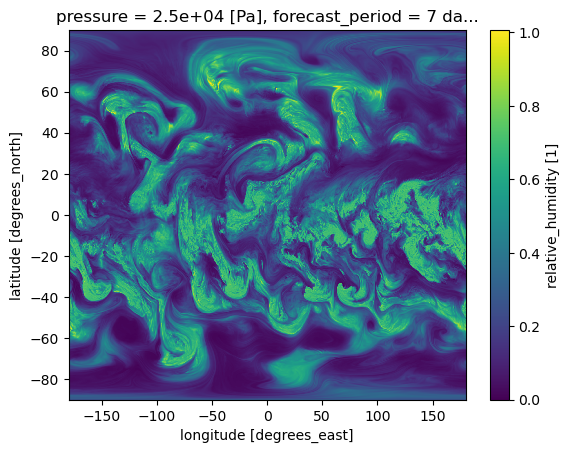

In [65]:
(global_rh_pressure_ds["relative_humidity"].isel(time=88, pressure=20).plot.imshow())